<div style="display: flex; flex-direction: row; justify-content: space-between; font-weight: bold; text-decoration: none">
<a href="01_data_cleaning.ipynb"><<< Back to Data Cleaning</a>
<a href="03_insights_and_visualizations.ipynb">Up Next: Insights and Data Visualizations >>></a>
</div>

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis (EDA)

### Loading the Merged Datasets

In [134]:
df = pd.read_csv('../data/cleaned/cleaned_data.csv')

Let's check to see the data types before proceeding with the exploration aspect, since we need to check if it got imported properly.

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279780 entries, 0 to 279779
Data columns (total 13 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   County                                           279756 non-null  object 
 1   City                                             279756 non-null  object 
 2   State                                            279780 non-null  object 
 3   Postal Code                                      279756 non-null  float64
 4   Model Year                                       279780 non-null  int64  
 5   Make                                             279780 non-null  object 
 6   Model                                            279780 non-null  object 
 7   Electric Vehicle Type                            279780 non-null  object 
 8   Clean Alternative Fuel Vehicle (CAFV) Eligible?  101843 non-null  object 
 9   Electric Range 

Since the Postal Code and Electric Range in Miles column turned into floats again (because of NaN values), let's convert the float values to Int64 (a nullable integer) again:

In [136]:
df['Postal Code'] = df['Postal Code'].astype('Int64')
df['Electric Range (in Miles)'] = df['Electric Range (in Miles)'].astype('Int64')
df.head()

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligible?,Electric Range (in Miles),Vehicle Location,Electric Utility,WA Retail Gas Prices (Dollars per Gallon)
0,Stevens,Colville,WA,99114,2012,NISSAN,LEAF,Battery Electric (BEV),True,73,POINT (-117.90454 48.54657),AVISTA CORP,3.883
1,Yakima,Yakima,WA,98903,2023,SUBARU,SOLTERRA,Battery Electric (BEV),NaN,<NA>,POINT (-120.71847 46.55029),PACIFICORP,4.541
2,King,Seattle,WA,98122,2018,NISSAN,LEAF,Battery Electric (BEV),True,151,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),3.269
3,Kitsap,Poulsbo,WA,98370,2025,BMW,X5,Plug-in Hybrid (PHEV),True,40,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,4.228
4,Thurston,Yelm,WA,98597,2015,FIAT,500,Battery Electric (BEV),True,87,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,2.754


We can get the summary statistics about this dataset by doing the following:

In [137]:
df.describe()

,Postal Code,Model Year,Electric Range (in Miles),WA Retail Gas Prices (Dollars per Gallon)
count,279756.0,279780.000000,101832.0,262363.000000
mean,98176.111447,2022.074072,107.620227,3.997542
std,2577.39804,3.059852,97.197987,0.622660
min,1030.0,1999.000000,1.0,1.684000
25%,98052.0,2021.000000,30.0,3.520000
50%,98133.0,2023.000000,47.0,4.162000
75%,98382.0,2024.000000,215.0,4.541000
max,99517.0,2027.000000,337.0,4.659000


I also want to check how many null values there are:

In [138]:
df.isnull().sum()

County                                                 24
City                                                   24
State                                                   0
Postal Code                                            24
Model Year                                              0
Make                                                    0
Model                                                   0
Electric Vehicle Type                                   0
Clean Alternative Fuel Vehicle (CAFV) Eligible?    177937
Electric Range (in Miles)                          177948
Vehicle Location                                      109
Electric Utility                                       24
WA Retail Gas Prices (Dollars per Gallon)           17417
dtype: int64

Seeing the above data, I realized that for the "Electric Range" and "Clean Alternative Fuel (CAFV) Eligible" columns, 177937 rows of the data are null out of 279780 rows (64%). 

As such, we will have to deal with the analysis done on those rows seperately, so that any queries that involve those columns are only done on a subset of the dataset, which is the 36% of the data that doesn't have null values for these columns.

In [139]:
# The following line will give you a vector of true/false values, which we can use to make a new dataframe of only those that say that there is data, hence the .notnull().
df['Electric Range (in Miles)'].notnull()
# We can define a new dataframe using the following:
df_elec = df[df['Electric Range (in Miles)'].notnull()]
df_elec.head()

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligible?,Electric Range (in Miles),Vehicle Location,Electric Utility,WA Retail Gas Prices (Dollars per Gallon)
0,Stevens,Colville,WA,99114,2012,NISSAN,LEAF,Battery Electric (BEV),True,73,POINT (-117.90454 48.54657),AVISTA CORP,3.883
2,King,Seattle,WA,98122,2018,NISSAN,LEAF,Battery Electric (BEV),True,151,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),3.269
3,Kitsap,Poulsbo,WA,98370,2025,BMW,X5,Plug-in Hybrid (PHEV),True,40,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,4.228
4,Thurston,Yelm,WA,98597,2015,FIAT,500,Battery Electric (BEV),True,87,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,2.754
5,Thurston,Olympia,WA,98502,2015,NISSAN,LEAF,Battery Electric (BEV),True,84,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,2.754


We can use the df_elec that we made when we have to analyze data that has values for the Electric Range column. This is useful in case we need to analyze only cars that have Electric Ranges.

In [140]:
df.nunique()

County                                              253
City                                                894
State                                                52
Postal Code                                        1119
Model Year                                           23
Make                                                 47
Model                                               187
Electric Vehicle Type                                 2
Clean Alternative Fuel Vehicle (CAFV) Eligible?       2
Electric Range (in Miles)                           112
Vehicle Location                                   1115
Electric Utility                                     77
WA Retail Gas Prices (Dollars per Gallon)            18
dtype: int64

After seeing that there are 52 unique states included in this dataset, I realized that I joined the EV dataset with an unsuitable gas dataset the first time. This is because the gas dataset only includes information about WA gas prices, but the EV dataset contains multiple states in it. 

As I was trying to find a new gas dataset to replace the gas dataset with, I found that when I merged the gas dataset and the EV dataset in the data cleaning file, I didn't account for differences in dataset granularity.

Merging each row in the EV dataset with a gas price joined on the year column would be inappropriate because there are only 18 gas prices, but each row in the EV dataset is a seperate car. 

This would cause a misrepresentation of gas price data because the gas price would be the same across multiple rows depending on the year and has no connection with each car. This would skew the data.

As such, I made the decision to drop the gas prices column, although it could be accounted for using aggregate values if this project was extended.

In [141]:
df = df.drop(columns='WA Retail Gas Prices (Dollars per Gallon)')
df

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligible?,Electric Range (in Miles),Vehicle Location,Electric Utility
0,Stevens,Colville,WA,99114,2012,NISSAN,LEAF,Battery Electric (BEV),True,73,POINT (-117.90454 48.54657),AVISTA CORP
1,Yakima,Yakima,WA,98903,2023,SUBARU,SOLTERRA,Battery Electric (BEV),NaN,<NA>,POINT (-120.71847 46.55029),PACIFICORP
2,King,Seattle,WA,98122,2018,NISSAN,LEAF,Battery Electric (BEV),True,151,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
3,Kitsap,Poulsbo,WA,98370,2025,BMW,X5,Plug-in Hybrid (PHEV),True,40,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC
4,Thurston,Yelm,WA,98597,2015,FIAT,500,Battery Electric (BEV),True,87,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC
...,...,...,...,...,...,...,...,...,...,...,...,...
279775,Clark,Washougal,WA,98671,2024,HONDA,PROLOGUE,Battery Electric (BEV),NaN,<NA>,POINT (-122.35341 45.57923),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...
279776,King,Seattle,WA,98103,2019,BMW,I3,Plug-in Hybrid (PHEV),True,126,POINT (-122.35436 47.67596),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
279777,King,Sammamish,WA,98075,2026,RIVIAN,R1S,Battery Electric (BEV),NaN,<NA>,POINT (-122.03539 47.61344),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
279778,Pierce,Bonney Lake,WA,98391,2026,TESLA,MODEL Y,Battery Electric (BEV),NaN,<NA>,POINT (-122.17144 47.19175),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)


In [142]:
df.sort_values(by='Electric Range (in Miles)', ascending=False).head()

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligible?,Electric Range (in Miles),Vehicle Location,Electric Utility
193258,King,Snoqualmie,WA,98065,2020,TESLA,MODEL S,Battery Electric (BEV),True,337,POINT (-121.82432 47.52716),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
152373,King,Issaquah,WA,98029,2020,TESLA,MODEL S,Battery Electric (BEV),True,337,POINT (-122.01656 47.57118),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
17474,King,Kent,WA,98032,2020,TESLA,MODEL S,Battery Electric (BEV),True,337,POINT (-122.23741 47.3807),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
79669,Clark,Vancouver,WA,98685,2020,TESLA,MODEL S,Battery Electric (BEV),True,337,POINT (-122.70303 45.70954),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...
78639,King,Redmond,WA,98053,2020,TESLA,MODEL S,Battery Electric (BEV),True,337,POINT (-122.03287 47.68555),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)


In [143]:
df.corr(numeric_only=True)

,Postal Code,Model Year,Electric Range (in Miles)
Postal Code,1.000000,-0.001499,-0.003093
Model Year,-0.001499,1.000000,-0.266765
Electric Range (in Miles),-0.003093,-0.266765,1.000000


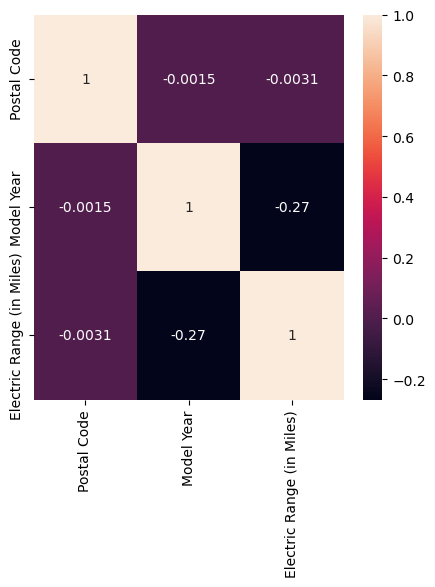

In [144]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.rcParams['figure.figsize'] = (5, 5)
plt.show()

In [145]:
df.groupby(['State', 'Make'])['Make'].count().sort_values(ascending=False)

State  Make         
WA     TESLA            114498
       CHEVROLET         19233
       NISSAN            16144
       FORD              15314
       KIA               13920
                         ...  
AZ     MERCEDES-BENZ         1
       VOLKSWAGEN            1
BC     VOLVO                 1
CA     AUDI                  1
       CADILLAC              1
Name: Make, Length: 299, dtype: int64

In [146]:
df_ev_type = df.groupby(['Model Year', 'Electric Vehicle Type'])['Electric Vehicle Type'].count().unstack()
df_ev_type

Electric Vehicle Type,Battery Electric (BEV),Plug-in Hybrid (PHEV)
Model Year,,
1999,2.0,NaN
2000,7.0,NaN
2002,1.0,NaN
2003,1.0,NaN
2008,19.0,NaN
2010,20.0,2.0
2011,521.0,57.0
2012,607.0,766.0
2013,2448.0,1503.0


<Axes: xlabel='Model Year'>

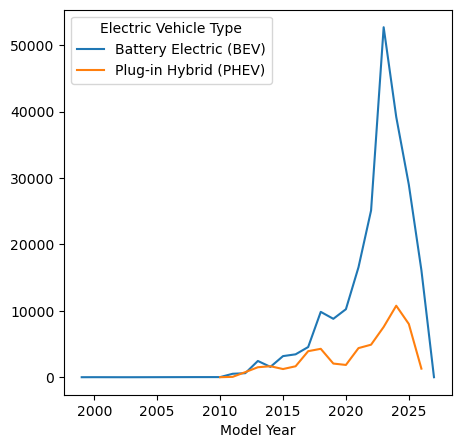

In [147]:
df_ev_type.plot()

<Axes: >

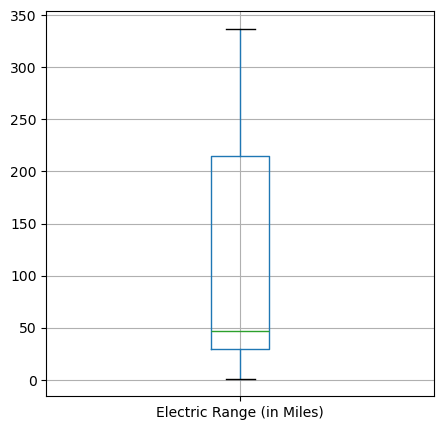

In [153]:
df_elec[['Electric Range (in Miles)']].boxplot()

<Axes: >

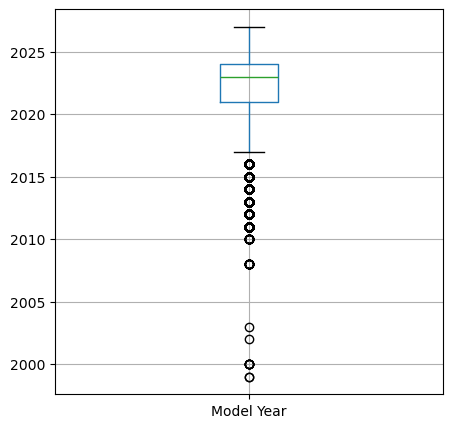

In [154]:
df[['Model Year']].boxplot()

In [156]:
df.select_dtypes(include='object')

,County,City,State,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligible?,Vehicle Location,Electric Utility
0,Stevens,Colville,WA,NISSAN,LEAF,Battery Electric (BEV),True,POINT (-117.90454 48.54657),AVISTA CORP
1,Yakima,Yakima,WA,SUBARU,SOLTERRA,Battery Electric (BEV),NaN,POINT (-120.71847 46.55029),PACIFICORP
2,King,Seattle,WA,NISSAN,LEAF,Battery Electric (BEV),True,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
3,Kitsap,Poulsbo,WA,BMW,X5,Plug-in Hybrid (PHEV),True,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC
4,Thurston,Yelm,WA,FIAT,500,Battery Electric (BEV),True,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC
...,...,...,...,...,...,...,...,...,...
279775,Clark,Washougal,WA,HONDA,PROLOGUE,Battery Electric (BEV),NaN,POINT (-122.35341 45.57923),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...
279776,King,Seattle,WA,BMW,I3,Plug-in Hybrid (PHEV),True,POINT (-122.35436 47.67596),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
279777,King,Sammamish,WA,RIVIAN,R1S,Battery Electric (BEV),NaN,POINT (-122.03539 47.61344),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
279778,Pierce,Bonney Lake,WA,TESLA,MODEL Y,Battery Electric (BEV),NaN,POINT (-122.17144 47.19175),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)


#### Objectives / Questions
**General Questions**
1) What are the top EV brands in Washington State?
    1) Of these top EV brands, which models are the most popular and least popular?
    2) Which counties have the highest concentration of these top EV brands?
3) Which counties and cities have the most EVs?
4) Which brands and models have the highest Electric Range and the lowest?

**Segmentation Questions**
If split by Hybrid Plug-In and Battery Electric:
1) What are the top five most popular cars in each category?
2) Which are the top five counties or cities in terms of each type Electric Vehicle type?
3) What is the distribution of cars by year (maybe as a line plot)? 
4) What are the max and min Electric ranges of these two Electric vehicle types (as a box and whiskers plot)?
5) How has the number of Battery Electric and Plug-In Hybrid changed over the years?
6) Are there any relationships we can see based on the trends in gas prices and model year between Battery Electric and Plug-In Hybrid?


If split by county:
1) What are the most popular and least popular brands and models in each county?
2) Which counties and of those counties, which cities have the most electric cars split by Electric Vehicle type?

If split by city:
1) How many cars are Battery Electric and Hybrid Plug-In in each city (as a stacked bar plot maybe)?


#### Exploratory Data Analysis

#### Brief Visual Analysis

<div style="display: flex; flex-direction: row; justify-content: space-between; font-weight: bold; text-decoration: none">
<a href="01_data_cleaning.ipynb"><<< Back to Data Cleaning</a>
<a href="03_insights_and_visualizations.ipynb">Up Next: Insights and Data Visualizations >>></a>
</div>